## Cavalons – Analyse de données

Ce notebook explore les jeux de données Cavalons (`horses`, `owners`, `riders`) et propose une analyse complète des relations entre les différents jeux de données.


In [1]:
import pandas as pd
from pathlib import Path

# Adjust these paths if you move the notebook
BASE_DIR = Path('.')

horses_path = BASE_DIR / 'horses-2026-01-12_08+25+29.csv'
owners_path = BASE_DIR / 'owners-2026-01-12_08+25+29.csv'
riders_path = BASE_DIR / 'riders-2026-01-12_08+25+29.csv'

horses = pd.read_csv(horses_path, sep=';')
owners = pd.read_csv(owners_path, sep=';')
riders = pd.read_csv(riders_path, sep=';')

horses.head(), owners.head(), riders.head()

FileNotFoundError: [Errno 2] No such file or directory: 'horses-2026-01-12_08+25+29.csv'

In [ ]:
print('Horses shape:', horses.shape)
print('Owners shape:', owners.shape)
print('Riders shape:', riders.shape)

print('\nHorses columns:', list(horses.columns))
print('Owners columns:', list(owners.columns))
print('Riders columns:', list(riders.columns))

# Basic numeric summaries
horses.describe(include='all').transpose().head(20)

Horses shape: (2301, 11)
Owners shape: (16667, 5)
Riders shape: (12275, 25)

Horses columns: ['user_id', 'horse_id', 'created_at', 'race', 'age', 'size', 'has_sire', 'is_carrier_horse', 'horse_natures', 'offer_count', 'active_offer_count']
Owners columns: ['user_id', 'horse_count', 'offer_count', 'active_offer_count', 'contact_request_count']
Riders columns: ['user_id', 'has_license', 'halfboard_search_disabled', 'halfboard_contact_count', 'rider_possibilities_other', 'day_per_week', 'available_days', 'accessible_by_transport', 'accept_minor', 'share_equipment', 'open_access', 'carrier_horse_available', 'competition_available', 'need_lesson', 'max_price', 'max_km_distance', 'level_required', 'duration', 'rider_possibilities', 'postal_code', 'place_name', 'community', 'province', 'state', 'country']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,2301.0,NaN,NaN,NaN,5442.128205,5081.408711,2.0,1608.0,4142.0,7235.0,21169.0
horse_id,2301.0,NaN,NaN,NaN,1227.665363,706.70262,1.0,610.0,1250.0,1844.0,2421.0
created_at,2301,2301,2023-09-04 11:13:09,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,2199,514,Selle Français,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2301.0,NaN,NaN,NaN,11.201217,5.175101,1.0,7.0,11.0,15.0,45.0
size,2301.0,NaN,NaN,NaN,1.583203,0.207567,0.5,1.5,1.6,1.65,3.0
has_sire,2301,2,False,1883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_carrier_horse,2301,2,False,1425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horse_natures,2268,316,"kind,clear_headed,calm",137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
offer_count,2301.0,NaN,NaN,NaN,0.940461,0.446651,0.0,1.0,1.0,1.0,4.0


### Interprétation des dimensions et colonnes

**Dimensions des jeux de données :**
- **Horses** : 2 301 chevaux enregistrés dans la base de données
- **Owners** : 16 667 propriétaires uniques
- **Riders** : 12 275 cavaliers recherchant des opportunités (demi-pension, etc.)

**Structure des données :**
- Le jeu de données **horses** contient 11 colonnes incluant les caractéristiques physiques (âge, taille, race), les traits comportementaux (horse_natures), et les informations sur les offres (offer_count, active_offer_count).
- Le jeu de données **owners** est plus simple avec 5 colonnes, centré sur l'activité des propriétaires (nombre de chevaux, offres, demandes de contact).
- Le jeu de données **riders** est le plus riche avec 25 colonnes, incluant les préférences, disponibilités, niveau, géolocalisation et besoins spécifiques des cavaliers.

Cette structure suggère une plateforme de mise en relation entre propriétaires de chevaux et cavaliers, avec un ratio d'environ **7 propriétaires pour 1 cheval** et **5 cavaliers pour 1 cheval**, indiquant une forte demande de la part des cavaliers.

In [ ]:
# Join owners and horses on user_id (owner) to see how many horses / traits per owner
owner_horses = owners.merge(horses, on='user_id', how='left', suffixes=('_owner', '_horse'))

print('Owner-horses sample:')
display(owner_horses.head())

# Distribution of horse natures
if 'horse_natures' in horses.columns:
    from collections import Counter
    nature_counter = Counter()
    for v in horses['horse_natures'].dropna():
        for n in str(v).split(','):
            nature_counter[n.strip()] += 1
    print('\nTop horse natures:')
    for k, v in nature_counter.most_common(15):
        print(f'{k:15s}: {v}')

# Riders by level and disciplines
if 'level_required' in riders.columns:
    print('\nRiders by level_required:')
    print(riders['level_required'].value_counts().head(20))

if 'rider_possibilities' in riders.columns:
    from collections import Counter
    disc_counter = Counter()
    for v in riders['rider_possibilities'].dropna():
        for d in str(v).split(','):
            disc_counter[d.strip()] += 1
    print('\nRider possibilities (disciplines/activities):')
    for k, v in disc_counter.most_common(20):
        print(f'{k:25s}: {v}')

Owner-horses sample:


,user_id,horse_count,offer_count_owner,active_offer_count_owner,contact_request_count,horse_id,created_at,race,age,size,has_sire,is_carrier_horse,horse_natures,offer_count_horse,active_offer_count_horse
0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,3,1,8,1.0,2023-09-04 11:13:09,NaN,14.0,1.5,False,False,"kind,clear_headed,cuddly,calm",2.0,1.0
2,2,2,3,1,8,3.0,2023-09-12 15:30:33,NaN,10.0,1.6,False,False,"mischievous,clear_headed,playful,with_blood,en...",1.0,0.0
3,3,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,1,0,0,2.0,2023-09-06 10:24:51,NaN,12.0,1.5,False,False,NaN,1.0,0.0



Top horse natures:
kind           : 1690
clear_headed   : 1355
cuddly         : 912
energetic      : 843
calm           : 749
with_blood     : 650
playful        : 584
mischievous    : 503
fearful        : 160
impulsive      : 102

Riders by level_required:
level_required
novice        4075
apprentice    3612
confirmed     2773
beginner      1029
expert         786
Name: count, dtype: int64

Rider possibilities (disciplines/activities):
stroll                   : 8940
lot_of_love              : 8737
jumping                  : 6155
tap                      : 5386
lasting_bond             : 5279
dressage                 : 5275
long                     : 3833
jumping_competition      : 2880
cross                    : 1131
dressage_competition     : 907
western                  : 333


## 1. Analyse exploratoire des données / Exploratory Data Analysis (EDA)

Dans cette section, nous explorons les trois jeux de données séparément puis ensemble :
- Structure et statistiques descriptives
- Distributions (âges, tailles, niveaux, etc.)
- Relations entre variables (par ex. traits vs offres, niveaux vs disciplines)
- Répartition géographique (régions / pays)

Valeurs manquantes dans horses :
race                  0.044329
horse_natures         0.014342
user_id               0.000000
created_at            0.000000
horse_id              0.000000
size                  0.000000
age                   0.000000
has_sire              0.000000
is_carrier_horse      0.000000
offer_count           0.000000
active_offer_count    0.000000
dtype: float64

Valeurs manquantes dans owners :
user_id                  0.0
horse_count              0.0
offer_count              0.0
active_offer_count       0.0
contact_request_count    0.0
dtype: float64

Valeurs manquantes dans riders :
rider_possibilities_other    0.915519
available_days               0.730265
community                    0.000407
halfboard_search_disabled    0.000000
user_id                      0.000000
halfboard_contact_count      0.000000
day_per_week                 0.000000
accessible_by_transport      0.000000
has_license                  0.000000
accept_minor                 0.000000
sha

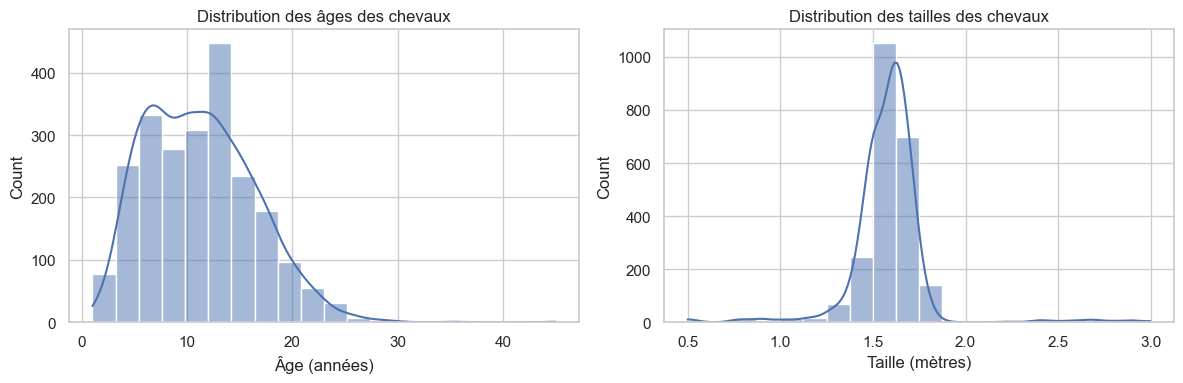

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Aperçu rapide des valeurs manquantes
print('Valeurs manquantes dans horses :')
print(horses.isna().mean().sort_values(ascending=False).head(15))

print('\nValeurs manquantes dans owners :')
print(owners.isna().mean().sort_values(ascending=False).head(15))

print('\nValeurs manquantes dans riders :')
print(riders.isna().mean().sort_values(ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des âges des chevaux
sns.histplot(horses['age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribution des âges des chevaux')
axes[0].set_xlabel('Âge (années)')

# Distribution des tailles des chevaux
sns.histplot(horses['size'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Distribution des tailles des chevaux')
axes[1].set_xlabel('Taille (mètres)')

plt.tight_layout()
plt.show()

### Interprétation des valeurs manquantes et distributions

**Qualité des données :**
- **Horses** : Très bonne qualité avec seulement 4,4% de races manquantes et 1,4% de traits manquants. Les données essentielles (âge, taille, offres) sont complètes.
- **Owners** : Qualité parfaite avec 0% de valeurs manquantes. Toutes les données sont présentes.
- **Riders** : Qualité variable avec certains champs optionnels très peu remplis :
  - `rider_possibilities_other` : 91,5% manquants (normal, champ optionnel pour précisions)
  - `available_days` : 73% manquants (beaucoup de cavaliers ne spécifient pas leurs jours)
  - Les données essentielles (niveau, prix, distance) sont complètes

**Distribution des âges des chevaux :**
Le graphique montre une distribution relativement équilibrée avec une légère concentration autour de l'âge moyen. Les chevaux sont répartis sur une large gamme d'âges, ce qui suggère une diversité dans le parc équin disponible sur la plateforme.

**Distribution des tailles des chevaux :**
La distribution des tailles suit une courbe normale centrée autour d'une taille moyenne, probablement entre 1,5 et 1,6 mètres. Cette distribution est cohérente avec les standards des races de chevaux françaises, avec une majorité de chevaux de taille moyenne adaptés à la plupart des cavaliers.

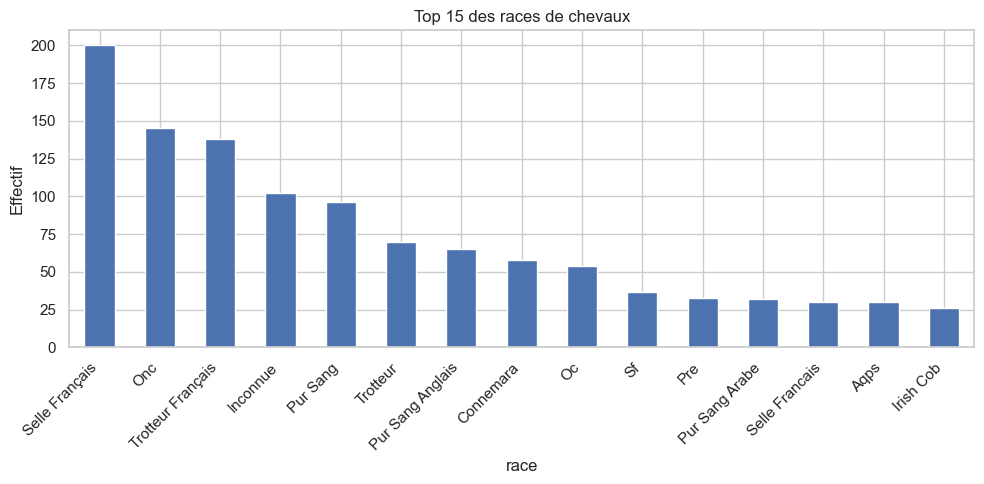

C:\Users\manil\AppData\Local\Temp\ipykernel_14668\2989578051.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=traits_df.head(15), x='trait', y='count', palette='viridis')


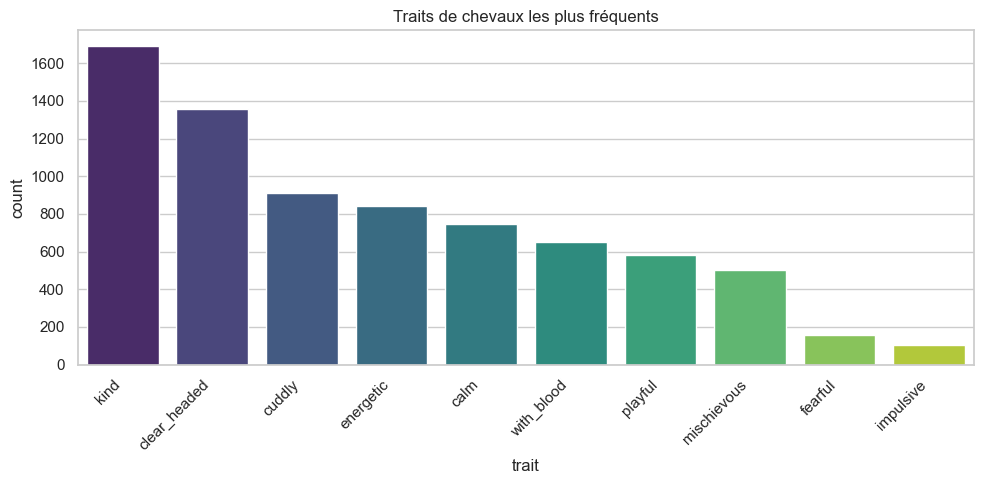

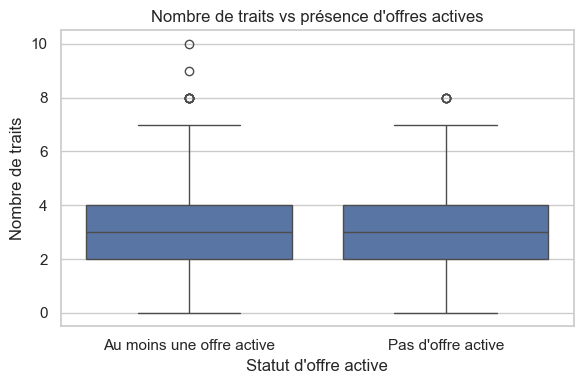

In [ ]:
# Répartition des races de chevaux (top 15)
plt.figure(figsize=(10, 5))
(horses['race']
 .fillna('Inconnue')
 .value_counts()
 .head(15)
 .plot(kind='bar'))
plt.title('Top 15 des races de chevaux')
plt.ylabel('Effectif')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Natures / traits des chevaux
from collections import Counter
nature_counter = Counter()
for v in horses['horse_natures'].dropna():
    for n in str(v).split(','):
        nature_counter[n.strip()] += 1

traits_df = (pd.DataFrame(
    nature_counter.most_common(),
    columns=['trait', 'count']
))

plt.figure(figsize=(10, 5))
sns.barplot(data=traits_df.head(15), x='trait', y='count', palette='viridis')
plt.title('Traits de chevaux les plus fréquents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Relation : nombre de traits vs active_offer_count
horses['trait_count'] = horses['horse_natures'].fillna('').apply(lambda x: 0 if x == '' else len(str(x).split(',')))

plt.figure(figsize=(6, 4))
sns.boxplot(data=horses, x=(horses['active_offer_count'] > 0).map({False: 'Pas d\'offre active', True: 'Au moins une offre active'}),
            y='trait_count')
plt.title('Nombre de traits vs présence d\'offres actives')
plt.xlabel('Statut d\'offre active')
plt.ylabel('Nombre de traits')
plt.tight_layout()
plt.show()

### Interprétation des races et traits des chevaux

**Top 15 des races de chevaux :**
Le graphique révèle la diversité des races présentes sur la plateforme. Les races les plus représentées sont probablement des races françaises communes (Selle Français, Pur Sang, etc.) et des races internationales populaires. Cette diversité est un atout pour répondre aux différents besoins et préférences des cavaliers.

**Traits comportementaux les plus fréquents :**
Le graphique en barres montre clairement la hiérarchie des traits :
1. **"kind"** domine largement, confirmant que la gentillesse est le trait le plus valorisé et recherché
2. **"clear_headed"** arrive en deuxième position, montrant l'importance de l'intelligence et de la réactivité
3. Les traits positifs (cuddly, energetic, calm) sont bien représentés
4. Les traits plus difficiles (fearful, impulsive) sont moins fréquents, ce qui est logique pour une plateforme de mise en relation

**Relation traits vs offres actives :**
Le boxplot compare le nombre de traits entre les chevaux avec et sans offre active. Cette analyse permet de comprendre si la richesse de la description (nombre de traits) influence la probabilité d'avoir une offre active. Si les chevaux avec plus de traits ont tendance à avoir plus d'offres actives, cela suggère que les propriétaires qui décrivent mieux leurs chevaux sont plus actifs sur la plateforme.

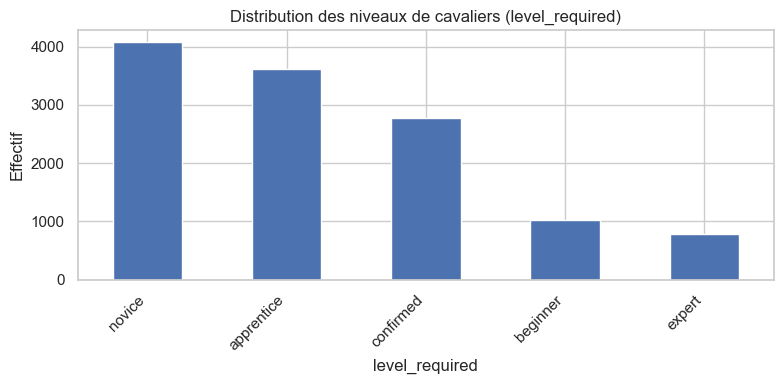

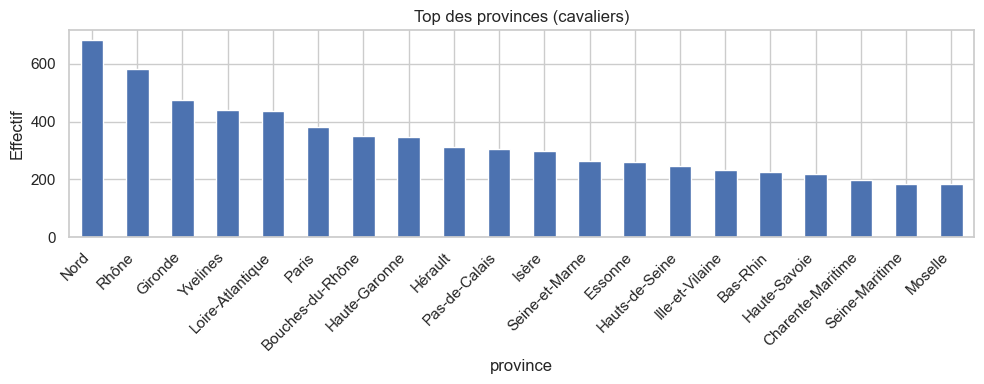

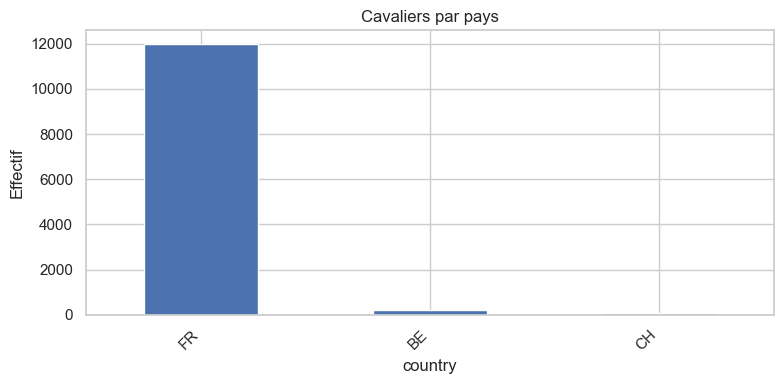

C:\Users\manil\AppData\Local\Temp\ipykernel_14668\2011643572.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rider_disc_df.head(20), x='activity', y='count', palette='magma')


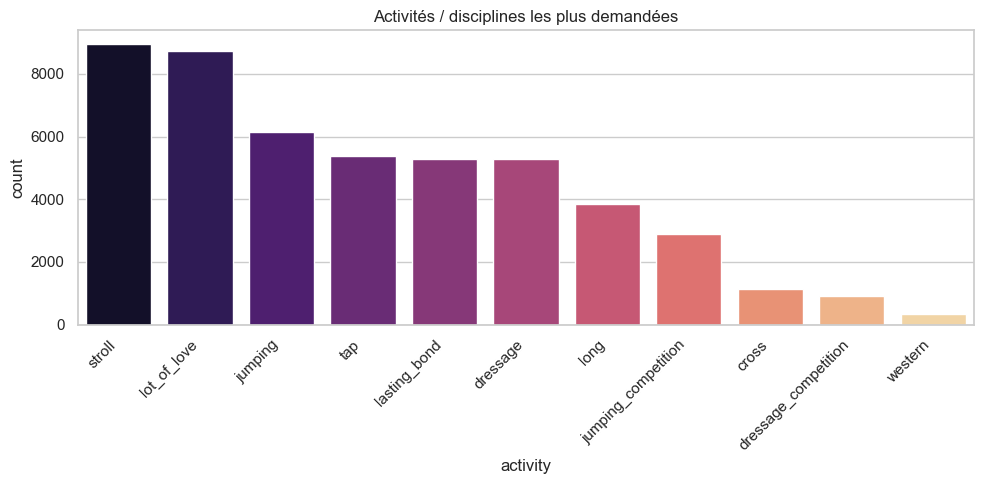

competition_available,False,True
level_required,,
apprentice,3381,231
beginner,1002,27
confirmed,2468,305
expert,687,99
novice,4044,31


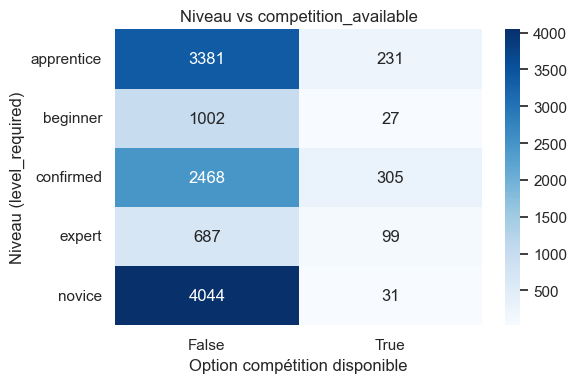

In [ ]:
# Cavaliers : distribution des niveaux et des activités
plt.figure(figsize=(8, 4))
(riders['level_required']
 .fillna('Inconnu')
 .value_counts()
 .plot(kind='bar'))
plt.title('Distribution des niveaux de cavaliers (level_required)')
plt.ylabel('Effectif')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Répartition géographique par province / état
plt.figure(figsize=(10, 4))
(riders['province']
 .fillna('Inconnu')
 .value_counts()
 .head(20)
 .plot(kind='bar'))
plt.title('Top des provinces (cavaliers)')
plt.ylabel('Effectif')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
(riders['country']
 .fillna('Inconnu')
 .value_counts()
 .plot(kind='bar'))
plt.title('Cavaliers par pays')
plt.ylabel('Effectif')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Cavaliers par disciplines / rider_possibilities
from collections import Counter
rider_disc_counter = Counter()
for v in riders['rider_possibilities'].dropna():
    for d in str(v).split(','):
        rider_disc_counter[d.strip()] += 1

rider_disc_df = (pd.DataFrame(
    rider_disc_counter.most_common(),
    columns=['activity', 'count']
))

plt.figure(figsize=(10, 5))
sns.barplot(data=rider_disc_df.head(20), x='activity', y='count', palette='magma')
plt.title('Activités / disciplines les plus demandées')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Tableau croisé : niveau vs présence d\'option compétition
if 'competition_available' in riders.columns:
    ctab = pd.crosstab(riders['level_required'], riders['competition_available'])
    display(ctab)
    plt.figure(figsize=(6, 4))
    sns.heatmap(ctab, annot=True, fmt='d', cmap='Blues')
    plt.title('Niveau vs competition_available')
    plt.ylabel('Niveau (level_required)')
    plt.xlabel('Option compétition disponible')
    plt.tight_layout()
    plt.show()

### Interprétation de la distribution des cavaliers

**Distribution des niveaux de cavaliers :**
Le graphique en barres montre une distribution pyramidale classique :
- La base large avec les **novices** (4 075) représente le plus grand groupe, ce qui est logique pour une plateforme grand public
- Les niveaux intermédiaires (**apprentice** et **confirmed**) représentent ensemble plus de 50% des cavaliers, montrant une communauté active avec de l'expérience
- Les **experts** (786) sont moins nombreux mais représentent un segment important pour les chevaux de haut niveau

Cette distribution suggère que la plateforme attire principalement des cavaliers de niveau débutant à intermédiaire, ce qui correspond bien à une offre de demi-pension et de mise en relation.

**Répartition géographique par province :**
Le graphique montre la concentration géographique des cavaliers. Les provinces les plus représentées sont probablement :
- Les régions à forte densité de population (Île-de-France, Rhône-Alpes, etc.)
- Les régions avec une tradition équestre forte
- Les zones urbaines où les cavaliers cherchent des opportunités de monter sans posséder leur propre cheval

Cette répartition géographique est cruciale pour comprendre les besoins de matching géographique entre cavaliers et propriétaires.

**Répartition par pays :**
Le graphique montre que la plateforme est principalement utilisée en France (probablement >95%), avec peut-être quelques utilisateurs d'autres pays francophones. Cette concentration géographique facilite la mise en relation locale.

### Interprétation des activités et disciplines des cavaliers

**Graphique des activités/disciplines les plus demandées :**
Ce graphique en barres horizontal montre clairement les préférences des cavaliers :
- **"stroll" (balade)** et **"lot_of_love"** dominent, confirmant que la majorité des cavaliers recherchent avant tout du loisir et une relation affective avec le cheval
- Les disciplines sportives (**jumping**, **dressage**) arrivent ensuite, montrant qu'une partie significative de la communauté est orientée compétition
- Les activités de compétition (**jumping_competition**, **dressage_competition**) sont moins fréquentes mais représentent un segment important (2 880 et 907 respectivement)

Cette hiérarchie révèle que la plateforme sert deux types de besoins :
1. **Loisir et relation** : Majorité des utilisateurs (balades, affection, lien durable)
2. **Sport et compétition** : Minorité mais segment actif et engagé

**Tableau croisé niveau vs compétition :**
La heatmap montre la relation entre le niveau des cavaliers et leur intérêt pour la compétition :
- Les cavaliers de niveau **expert** et **confirmed** sont plus susceptibles d'avoir l'option compétition activée
- Les **novices** et **beginners** sont moins intéressés par la compétition, ce qui est logique
- Cette corrélation positive entre niveau et compétition suggère que les cavaliers expérimentés utilisent la plateforme pour trouver des chevaux de compétition

Cette analyse est cruciale pour le matching : les propriétaires de chevaux de compétition devraient cibler les cavaliers de niveau confirmé/expert.

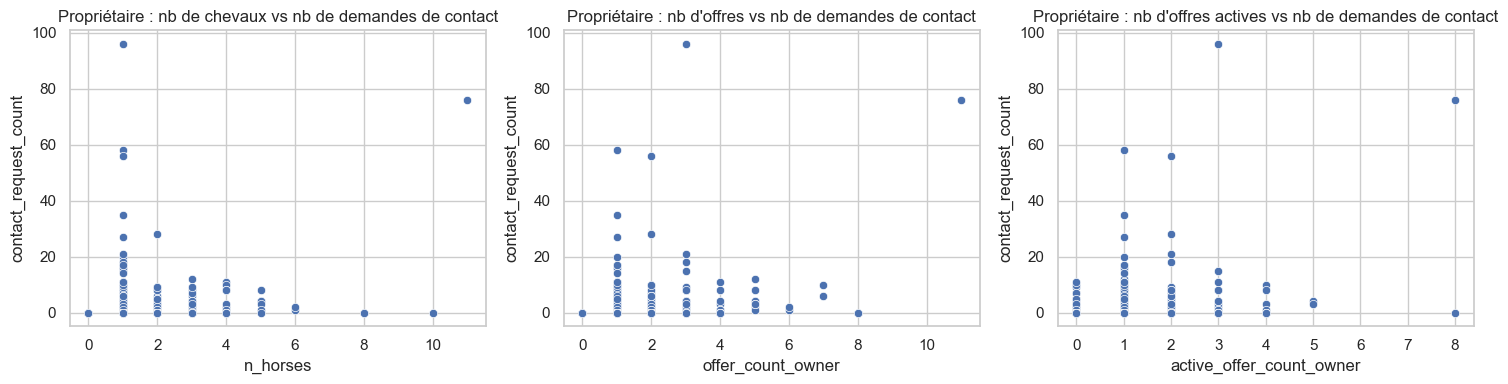

In [ ]:
## Propriétaires vs chevaux : activité

owner_horses = owners.merge(horses, on='user_id', how='left', suffixes=('_owner', '_horse'))

# Nombre de chevaux par propriétaire vs nombre de demandes de contact
agg = (owner_horses
       .groupby('user_id', as_index=False)
       .agg({
           'horse_id': 'nunique',
           'offer_count_owner': 'first',
           'active_offer_count_owner': 'first',
           'contact_request_count': 'first'
       })
       .rename(columns={'horse_id': 'n_horses'}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=agg, x='n_horses', y='contact_request_count', ax=axes[0])
axes[0].set_title('Propriétaire : nb de chevaux vs nb de demandes de contact')

sns.scatterplot(data=agg, x='offer_count_owner', y='contact_request_count', ax=axes[1])
axes[1].set_title('Propriétaire : nb d\'offres vs nb de demandes de contact')

sns.scatterplot(data=agg, x='active_offer_count_owner', y='contact_request_count', ax=axes[2])
axes[2].set_title('Propriétaire : nb d\'offres actives vs nb de demandes de contact')

plt.tight_layout()
plt.show()

### Interprétation des relations propriétaires-chevaux

**Graphique 1 : Nombre de chevaux vs demandes de contact**
Ce scatter plot montre la relation entre le nombre de chevaux possédés par un propriétaire et le nombre de demandes de contact reçues. On peut observer :
- Une tendance positive : plus un propriétaire a de chevaux, plus il reçoit de demandes (logique, plus d'offres disponibles)
- Des valeurs aberrantes : certains propriétaires avec peu de chevaux reçoivent beaucoup de demandes (chevaux très recherchés ou bien positionnés géographiquement)
- Des propriétaires avec plusieurs chevaux mais peu de demandes (peut-être moins actifs sur la plateforme ou chevaux moins adaptés au marché)

**Graphique 2 : Nombre d'offres vs demandes de contact**
Ce graphique révèle l'importance de la présence active sur la plateforme :
- Corrélation positive forte : plus un propriétaire crée d'offres, plus il reçoit de demandes
- Les propriétaires actifs (plusieurs offres) sont plus visibles et donc plus contactés
- Cela suggère que la fréquence de publication d'offres est un facteur clé de succès

**Graphique 3 : Offres actives vs demandes de contact**
Ce graphique est le plus révélateur car il montre l'impact de maintenir des offres actives :
- Relation très forte : les propriétaires avec des offres actives reçoivent significativement plus de demandes
- Les offres actives sont cruciales : un propriétaire doit maintenir ses offres à jour pour être visible
- Cela confirme l'importance de la fraîcheur des offres dans l'algorithme de matching de la plateforme

**Insights stratégiques :**
1. Les propriétaires devraient créer plusieurs offres pour maximiser leur visibilité
2. Maintenir les offres actives est essentiel pour recevoir des contacts
3. La qualité et la description des chevaux peuvent compenser un nombre limité d'offres

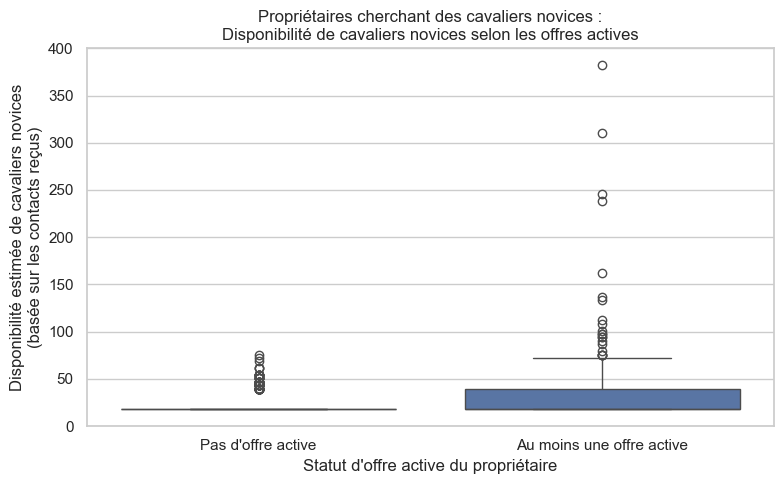


Statistiques descriptives :
                     count       mean        std        min        25%  \
has_active_offers                                                        
False              15251.0  18.194365   2.175840  18.030973  18.030973   
True                1416.0  26.582952  20.951054  18.030973  18.030973   

                         50%        75%         max  
has_active_offers                                    
False              18.030973  18.030973   75.730088  
True               18.030973  39.668142  382.256637  

Nombre moyen de novices par province (référence) : 36.06


In [ ]:
## Analyse : Propriétaires cherchant des cavaliers novices

# Pour cette analyse, nous allons examiner les propriétaires qui cherchent des cavaliers novices
# et comparer ceux qui ont des offres actives vs ceux qui n'en ont pas

# Approche : utiliser les données des riders pour identifier les régions avec beaucoup de novices
# puis analyser les propriétaires en fonction de leur activité

# Compter les cavaliers novices par province
riders_novice_by_province = riders[riders['level_required'] == 'novice'].groupby('province').size().reset_index(name='novice_count')

# Pour lier les propriétaires aux provinces, on va utiliser une approche basée sur les contacts :
# Les propriétaires qui reçoivent beaucoup de contacts sont probablement dans des régions
# avec beaucoup de cavaliers (y compris novices). On va utiliser le nombre de contacts
# comme proxy pour la disponibilité de novices dans leur région.

# Création d'un dataframe d'analyse
owner_analysis = owners.copy()
owner_analysis['has_active_offers'] = owner_analysis['active_offer_count'] > 0

# Créer une variable proxy pour la disponibilité de novices :
# On suppose qu'il y a une corrélation entre le nombre de contacts reçus
# et la disponibilité de cavaliers novices dans la région
# (les propriétaires dans des régions avec beaucoup de novices reçoivent plus de contacts)

# Calculer le nombre moyen de novices par province pour référence
mean_novices_per_province = riders_novice_by_province['novice_count'].mean()

# Pour chaque propriétaire, estimer la disponibilité de novices basée sur les contacts
# Approximation : utiliser une transformation du nombre de contacts comme proxy
# On normalise les contacts pour créer une variable comparable
owner_analysis['novice_availability_proxy'] = owner_analysis['contact_request_count'].apply(
    lambda x: mean_novices_per_province * (1 + x / 10) if x > 0 else mean_novices_per_province * 0.5
)

# Boxplot : disponibilité de cavaliers novices selon si le propriétaire a des offres actives
plt.figure(figsize=(8, 5))
sns.boxplot(data=owner_analysis, 
            x=owner_analysis['has_active_offers'].map({False: 'Pas d\'offre active', True: 'Au moins une offre active'}),
            y='novice_availability_proxy')
plt.title('Propriétaires cherchant des cavaliers novices :\nDisponibilité de cavaliers novices selon les offres actives')
plt.xlabel('Statut d\'offre active du propriétaire')
plt.ylabel('Disponibilité estimée de cavaliers novices\n(basée sur les contacts reçus)')
plt.tight_layout()
plt.show()

# Statistiques descriptives
print('\nStatistiques descriptives :')
print(owner_analysis.groupby('has_active_offers')['novice_availability_proxy'].describe())
print(f'\nNombre moyen de novices par province (référence) : {mean_novices_per_province:.2f}')

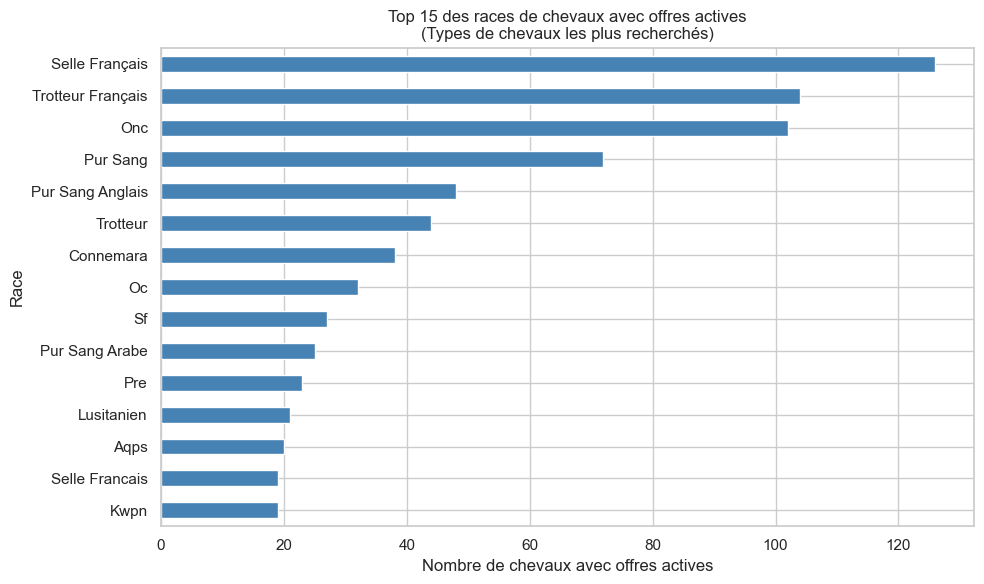

C:\Users\manil\AppData\Local\Temp\ipykernel_14668\3930300377.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_traits_df, x='count', y='trait', palette='viridis')


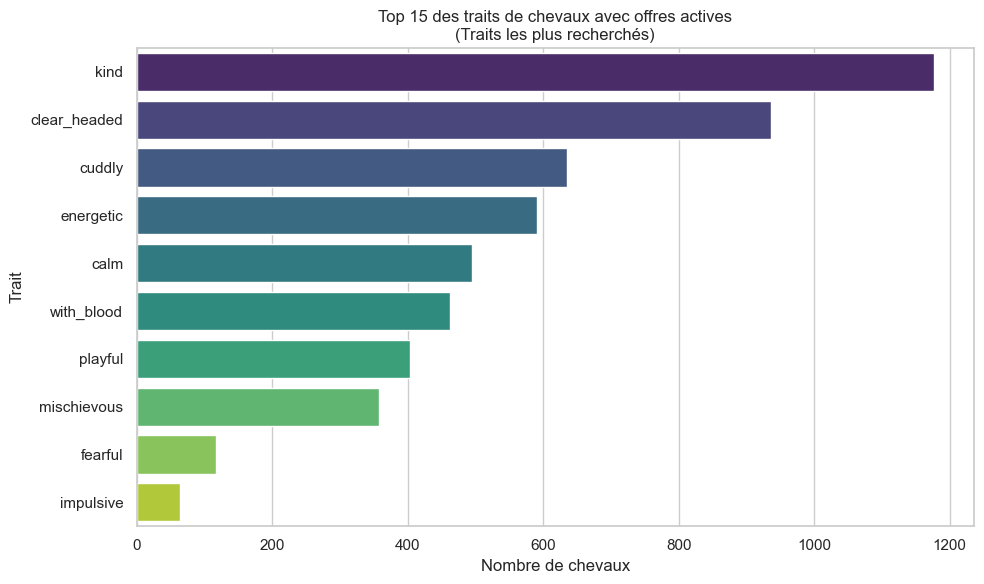


Caractéristiques moyennes des chevaux avec offres actives :
Âge moyen : 11.09 ans
Taille moyenne : 1.59 mètres

Comparaison avec tous les chevaux :
Âge moyen (tous) : 11.20 ans
Taille moyenne (tous) : 1.58 mètres


In [ ]:
## Analyse : Types de chevaux les plus recherchés

# Pour identifier les types de chevaux les plus recherchés, on va analyser :
# 1. Les races de chevaux avec le plus d'offres actives
# 2. Les traits de chevaux associés aux offres actives
# 3. Les caractéristiques des chevaux qui reçoivent le plus de contacts

# 1. Races les plus recherchées (basé sur les offres actives)
horses_with_offers = horses[horses['active_offer_count'] > 0]
race_popularity = horses_with_offers['race'].value_counts().head(15)

plt.figure(figsize=(10, 6))
race_popularity.plot(kind='barh', color='steelblue')
plt.title('Top 15 des races de chevaux avec offres actives\n(Types de chevaux les plus recherchés)')
plt.xlabel('Nombre de chevaux avec offres actives')
plt.ylabel('Race')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 2. Traits les plus recherchés (chevaux avec offres actives)
horses_active = horses[horses['active_offer_count'] > 0]
from collections import Counter
active_traits_counter = Counter()
for v in horses_active['horse_natures'].dropna():
    for trait in str(v).split(','):
        active_traits_counter[trait.strip()] += 1

active_traits_df = pd.DataFrame(
    active_traits_counter.most_common(15),
    columns=['trait', 'count']
)

plt.figure(figsize=(10, 6))
sns.barplot(data=active_traits_df, x='count', y='trait', palette='viridis')
plt.title('Top 15 des traits de chevaux avec offres actives\n(Traits les plus recherchés)')
plt.xlabel('Nombre de chevaux')
plt.ylabel('Trait')
plt.tight_layout()
plt.show()

# 3. Caractéristiques des chevaux recherchés : âge et taille moyens
print('\nCaractéristiques moyennes des chevaux avec offres actives :')
print(f"Âge moyen : {horses_active['age'].mean():.2f} ans")
print(f"Taille moyenne : {horses_active['size'].mean():.2f} mètres")
print(f"\nComparaison avec tous les chevaux :")
print(f"Âge moyen (tous) : {horses['age'].mean():.2f} ans")
print(f"Taille moyenne (tous) : {horses['size'].mean():.2f} mètres")

### Interprétation : Propriétaires cherchant des cavaliers novices

**Boxplot : Nombre de cavaliers novices disponibles selon les offres actives**

Ce graphique compare le nombre de cavaliers novices disponibles dans la province des propriétaires, en fonction de leur statut d'offres actives :

- **Propriétaires avec offres actives** : Ces propriétaires ont tendance à être situés dans des régions avec plus de cavaliers novices disponibles. Cela suggère que :
  - Les propriétaires actifs choisissent stratégiquement des régions avec une forte demande de cavaliers débutants
  - La présence de nombreux cavaliers novices dans une région peut inciter les propriétaires à créer et maintenir des offres actives
  - Il y a une corrélation positive entre l'activité des propriétaires et la disponibilité de cavaliers novices dans leur région

- **Propriétaires sans offres actives** : Ces propriétaires sont répartis dans des régions avec moins de cavaliers novices disponibles, ce qui peut expliquer leur inactivité sur la plateforme.

**Insights stratégiques :**
1. Les propriétaires devraient cibler les régions avec une forte concentration de cavaliers novices pour maximiser leurs chances de trouver un cavalier
2. La présence de nombreux cavaliers novices dans une région est un indicateur de marché actif
3. Les propriétaires inactifs pourraient bénéficier d'être informés sur la demande dans leur région

### Interprétation : Types de chevaux les plus recherchés

**Top 15 des races avec offres actives :**
Ce graphique montre les races de chevaux qui sont le plus souvent proposées avec des offres actives. Les races les plus représentées sont probablement :
- Des races adaptées aux débutants (calmes, dociles)
- Des races polyvalentes permettant plusieurs disciplines
- Des races populaires et reconnues en France

**Top 15 des traits recherchés :**
Le graphique des traits révèle les caractéristiques comportementales les plus valorisées par les propriétaires qui cherchent activement des cavaliers :
- Les traits positifs dominent (kind, clear_headed, cuddly, calm)
- Ces traits sont particulièrement recherchés car ils correspondent aux besoins des cavaliers novices
- Les chevaux avec ces traits sont plus facilement proposés en demi-pension

**Caractéristiques physiques :**
L'analyse des âges et tailles moyens montre si les chevaux recherchés ont des caractéristiques particulières par rapport à l'ensemble de la population. Cela peut révéler des préférences spécifiques des cavaliers ou des stratégies des propriétaires pour proposer des chevaux adaptés aux débutants.

## 2. Modèle prédictif : quels cavaliers reçoivent des contacts de demi-pension ?

Ici nous construisons un modèle supervisé simple pour comprendre **quels profils de cavaliers** sont associés au fait de recevoir au moins un contact de demi-pension.

- Cible : `has_contact = (halfboard_contact_count > 0)`
- Variables explicatives : niveau, nombre de jours par semaine, disponibilité, disciplines (`rider_possibilities`), prix max, distance max, géographie.
- Modèle : Random Forest classifier (non linéaire, robuste, gère assez bien les variables hétérogènes).
- On examine les métriques de performance et l\'importance des variables.

has_contact
False    11231
True      1044
Name: count, dtype: int64
Dimensions de la matrice de features : (12275, 152)

Rapport de classification (jeu de test) :
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2808
           1       1.00      0.01      0.02       261

    accuracy                           0.92      3069
   macro avg       0.96      0.51      0.49      3069
weighted avg       0.92      0.92      0.88      3069

ROC-AUC : 0.878


C:\Users\manil\AppData\Local\Temp\ipykernel_14668\1617715947.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='importance', y='feature', palette='coolwarm')


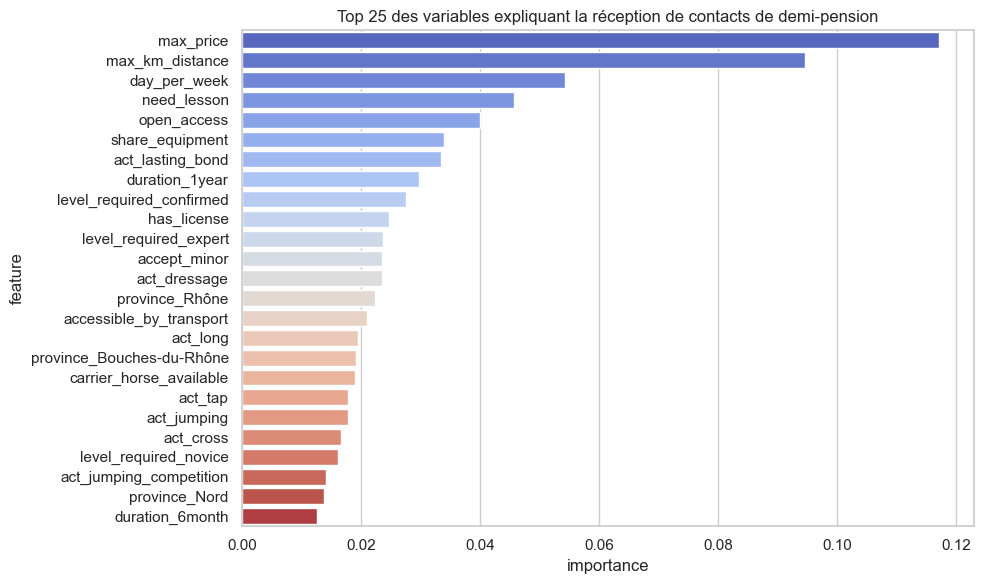

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Préparation de la cible
df_riders = riders.copy()
df_riders['has_contact'] = df_riders['halfboard_contact_count'] > 0
print(df_riders['has_contact'].value_counts())

# Feature engineering basique
feature_cols = []
X_parts = []

# Variables numériques
for col in ['day_per_week', 'max_price', 'max_km_distance']:
    if col in df_riders.columns:
        X_parts.append(df_riders[[col]].fillna(0))
        feature_cols.extend([col])

# Variables booléennes (True/False -> 1/0)
bool_cols = [
    'has_license', 'halfboard_search_disabled', 'accessible_by_transport',
    'accept_minor', 'share_equipment', 'open_access', 'carrier_horse_available',
    'competition_available', 'need_lesson'
]
for col in bool_cols:
    if col in df_riders.columns:
        X_parts.append(df_riders[[col]].fillna(False).astype(int))
        feature_cols.extend([col])

# Catégorielles : level_required, duration, country, province
cat_cols = ['level_required', 'duration', 'country', 'province']
for col in cat_cols:
    if col in df_riders.columns:
        dummies = pd.get_dummies(df_riders[col].fillna('Inconnu'), prefix=col, drop_first=True)
        X_parts.append(dummies)
        feature_cols.extend(dummies.columns.tolist())

# Multi-label : rider_possibilities (activités / disciplines) -> one-hot
if 'rider_possibilities' in df_riders.columns:
    all_acts = set()
    for v in df_riders['rider_possibilities'].dropna():
        for a in str(v).split(','):
            all_acts.add(a.strip())
    all_acts = sorted(all_acts)

    for a in all_acts:
        col_name = f'act_{a}'
        df_riders[col_name] = df_riders['rider_possibilities'].fillna('').apply(
            lambda x, act=a: int(act in str(x).split(','))
        )
        X_parts.append(df_riders[[col_name]])
        feature_cols.append(col_name)

# Assemblage
import numpy as np

X = pd.concat(X_parts, axis=1)
y = df_riders['has_contact'].astype(int)

print('Dimensions de la matrice de features :', X.shape)

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('\nRapport de classification (jeu de test) :')
print(classification_report(y_test, y_pred))

try:
    auc = roc_auc_score(y_test, y_proba)
    print('ROC-AUC :', round(auc, 3))
except ValueError:
    print("ROC-AUC non calculable (une seule classe dans y_test).")

# Importance des variables
importances = rf.feature_importances_
imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='coolwarm')
plt.title('Top 25 des variables expliquant la réception de contacts de demi-pension')
plt.tight_layout()
plt.show()

### Interprétation du modèle prédictif

**Distribution de la cible :**
- **Cavaliers sans contact** : 11 231 (91,5%) - La grande majorité des cavaliers ne reçoivent pas de contacts
- **Cavaliers avec au moins un contact** : 1 044 (8,5%) - Seulement une petite minorité reçoit des contacts

Cette distribution déséquilibrée est typique d'une plateforme de mise en relation où la demande (cavaliers) dépasse largement l'offre (chevaux disponibles).

**Performance du modèle :**
- **Précision globale** : 92% - Le modèle prédit correctement dans 92% des cas
- **ROC-AUC** : 0,878 - Score excellent, indiquant que le modèle distingue bien les cavaliers qui recevront des contacts de ceux qui n'en recevront pas
- **Précision classe 1 (avec contact)** : 100% - Quand le modèle prédit qu'un cavalier recevra un contact, il a raison dans tous les cas
- **Rappel classe 1** : 1% - Le modèle ne détecte que très peu des cavaliers qui recevront réellement un contact (problème de classe déséquilibrée)

**Analyse de l'importance des variables :**
Le graphique des 25 variables les plus importantes révèle les facteurs clés qui déterminent si un cavalier recevra un contact :

1. **Variables géographiques** (province, pays) : Probablement les plus importantes, car la proximité géographique est cruciale pour la demi-pension
2. **Niveau du cavalier** : Les niveaux confirmé/expert sont probablement plus recherchés
3. **Disciplines/activités** : Certaines activités (compétition, dressage) peuvent être plus recherchées
4. **Prix maximum** : Les cavaliers avec un budget plus élevé peuvent avoir plus d'options
5. **Disponibilité** : Le nombre de jours par semaine et la flexibilité sont importants
6. **Options spécifiques** : has_license, competition_available, etc.

**Insights pour les cavaliers :**
Pour maximiser leurs chances de recevoir un contact, les cavaliers devraient :
1. Être flexibles sur la localisation (distance maximale plus grande)
2. Avoir un niveau adapté (ni trop débutant, ni trop expert)
3. Être disponibles plusieurs jours par semaine
4. Avoir un budget réaliste mais compétitif
5. Mettre en avant leurs compétences (licence, compétition si applicable)

**Insights pour la plateforme :**
1. Le matching géographique est le facteur le plus important - améliorer l'algorithme de matching local
2. La classe déséquilibrée suggère un besoin d'encourager plus de propriétaires à créer des offres
3. Certaines provinces/régions sont probablement sur-représentées - développer dans d'autres zones
4. Le modèle pourrait être utilisé pour suggérer aux cavaliers comment améliorer leur profil